# 🫁 Chest X-Ray Classification — EfficientNetV2B3
**Dataset:** Mendeley Chest X-Ray Dataset (9xkhgts2s6)  
**Model:** EfficientNetV2B3 (Transfer Learning)  
**Features:** Auto-resume, Train/Val/Test split, High Accuracy


In [6]:
# ── RESET WORKSPACE ───────────────────────────────────────────────────────────
import shutil, os
WORK_DIR_RESET = './efficientnetv2b3_workspace'
if os.path.exists(WORK_DIR_RESET):
    shutil.rmtree(WORK_DIR_RESET)
    print(f'✅ Old workspace deleted: {WORK_DIR_RESET}')
else:
    print('ℹ️ No old workspace found — clean start')


✅ Old workspace deleted: ./efficientnetv2b3_workspace


In [7]:
# ── 1. INSTALL DEPENDENCIES ──────────────────────────────────────────────────
# !pip install tensorflow scikit-learn matplotlib seaborn pandas numpy tqdm

In [8]:
# ── 2. IMPORTS ────────────────────────────────────────────────────────────────
import os
import json
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2B3
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print(f'TensorFlow version: {tf.__version__}')
print(f'GPUs available: {tf.config.list_physical_devices("GPU")}')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.21.0
GPUs available: []


In [9]:
# ── 3. CONFIGURATION ──────────────────────────────────────────────────────────
# EfficientNetV2B3 optimal input: 300x300
DATASET_ROOT  = r'C:\Users\Admin\Desktop\dataset train\Dataset'
WORK_DIR      = './efficientnetv2b3_workspace'

IMG_SIZE      = (300, 300)   # EfficientNetV2B3 default
BATCH_SIZE    = 24           # smaller batch for larger images
EPOCHS_FROZEN = 10
EPOCHS_FINE   = 30
LEARNING_RATE = 1e-3
FINE_LR       = 1e-5

TRAIN_RATIO   = 0.70
VAL_RATIO     = 0.15
TEST_RATIO    = 0.15

MODEL_NAME    = 'EfficientNetV2B3'

os.makedirs(WORK_DIR, exist_ok=True)
print('Config ready ✅')

Config ready ✅


In [10]:
# ── 4. BUILD / LOAD SPLIT (resume-safe) ───────────────────────────────────────
SPLIT_CSV = os.path.join(WORK_DIR, 'data_split.csv')

def build_split(dataset_root, train_r, val_r, test_r, seed):
    records = []
    dataset_root = Path(dataset_root)
    for cls_dir in sorted(dataset_root.iterdir()):
        if not cls_dir.is_dir():
            continue
        label = cls_dir.name
        files = [str(p) for p in cls_dir.glob('**/*') if p.suffix.lower() in ('.jpg', '.jpeg', '.png')]
        for f in files:
            records.append({'filepath': f, 'label': label})
    df = pd.DataFrame(records)
    print(f'Total images: {len(df)}')
    print(df['label'].value_counts())

    train_df, tmp_df = train_test_split(df, test_size=(1 - train_r), stratify=df['label'], random_state=seed)
    rel_val = val_r / (val_r + test_r)
    val_df, test_df = train_test_split(tmp_df, test_size=(1 - rel_val), stratify=tmp_df['label'], random_state=seed)

    train_df = train_df.copy(); train_df['split'] = 'train'
    val_df   = val_df.copy();   val_df['split']   = 'val'
    test_df  = test_df.copy();  test_df['split']  = 'test'
    return pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

if os.path.exists(SPLIT_CSV):
    print('⚡ Loading saved split (resume mode) ...')
    df_split = pd.read_csv(SPLIT_CSV)
else:
    print('🔨 Building new split ...')
    df_split = build_split(DATASET_ROOT, TRAIN_RATIO, VAL_RATIO, TEST_RATIO, SEED)
    df_split.to_csv(SPLIT_CSV, index=False)
    print(f'Saved → {SPLIT_CSV}')

train_df = df_split[df_split['split'] == 'train'].reset_index(drop=True)
val_df   = df_split[df_split['split'] == 'val'].reset_index(drop=True)
test_df  = df_split[df_split['split'] == 'test'].reset_index(drop=True)

CLASS_NAMES = sorted(df_split['label'].unique().tolist())
NUM_CLASSES = len(CLASS_NAMES)
label2idx   = {c: i for i, c in enumerate(CLASS_NAMES)}

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

🔨 Building new split ...
Total images: 9209
label
Normal                 3271
Pneumonia-Bacterial    3001
Pneumonia-Viral        1656
COVID                  1281
Name: count, dtype: int64
Saved → ./efficientnetv2b3_workspace\data_split.csv
Train: 6446 | Val: 1381 | Test: 1382
Classes (4): ['COVID', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [11]:
# ── 5. DATA GENERATORS ────────────────────────────────────────────────────────
# EfficientNetV2 has built-in preprocessing — no manual rescaling needed
# But we apply it via preprocess_input
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

def make_gen(datagen, df, shuffle=True):
    return datagen.flow_from_dataframe(
        dataframe=df, x_col='filepath', y_col='label',
        target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', classes=CLASS_NAMES,
        shuffle=shuffle, seed=SEED
    )

train_gen = make_gen(train_datagen, train_df)
val_gen   = make_gen(val_test_datagen, val_df, shuffle=False)
test_gen  = make_gen(val_test_datagen, test_df, shuffle=False)

Found 6446 validated image filenames belonging to 4 classes.
Found 1381 validated image filenames belonging to 4 classes.
Found 1382 validated image filenames belonging to 4 classes.


In [12]:
# ── 6. CLASS WEIGHTS ──────────────────────────────────────────────────────────
y_train = train_df['label'].map(label2idx).values
cw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train)
class_weights = {i: w for i, w in enumerate(cw)}
print('Class weights:', class_weights)

Class weights: {0: 1.7965440356744704, 1: 0.7040192223678462, 2: 0.7670157068062827, 3: 1.3904227782571181}


In [13]:
# ── 7. BUILD MODEL ────────────────────────────────────────────────────────────
def build_efficientnetv2b3(num_classes, img_size):
    base = EfficientNetV2B3(
        include_top=False,
        weights='imagenet',
        input_shape=(*img_size, 3),
        include_preprocessing=True   # built-in preprocessing
    )
    base.trainable = False

    inputs = keras.Input(shape=(*img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(640, activation='swish', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.45)(x)
    x = layers.Dense(320, activation='swish', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs), base

model, base_model = build_efficientnetv2b3(NUM_CLASSES, IMG_SIZE)
model.summary()

52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 794s 15us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b3 (Functional)  │ (None, 10, 10, 1536)   │    12,930,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 640)            │       983,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 320)            │       205,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,284 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,126,850 (53.89 MB)

 Trainable params: 1,193,156 (4.55 MB)

 Non-trainable params: 12,933,694 (49.34 MB)

In [14]:
# ── 8. CALLBACKS & STATE ──────────────────────────────────────────────────────
CKPT_FROZEN = os.path.join(WORK_DIR, 'ckpt_phase1_frozen.keras')
CKPT_FINE   = os.path.join(WORK_DIR, 'ckpt_phase2_finetune.keras')
BEST_MODEL  = os.path.join(WORK_DIR, 'best_model.keras')
LOG_FROZEN  = os.path.join(WORK_DIR, 'log_phase1.csv')
LOG_FINE    = os.path.join(WORK_DIR, 'log_phase2.csv')
STATE_FILE  = os.path.join(WORK_DIR, 'train_state.json')

def get_callbacks(ckpt, log):
    return [
        ModelCheckpoint(ckpt, monitor='val_accuracy', save_best_only=True, verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-7, verbose=1),
        CSVLogger(log, append=True)
    ]

def save_state(phase):
    with open(STATE_FILE, 'w') as f:
        json.dump({'completed_phase': phase}, f)

def load_state():
    if os.path.exists(STATE_FILE):
        with open(STATE_FILE) as f:
            return json.load(f).get('completed_phase', 0)
    return 0

completed_phase = load_state()
print(f'Resuming from phase: {completed_phase}')

Resuming from phase: 0


In [15]:
# ── 9. PHASE 1 — FROZEN TRAINING ──────────────────────────────────────────────
if completed_phase < 1:
    print('\n🚀 Phase 1: Head training (EfficientNetV2B3 frozen) ...')

    if os.path.exists(CKPT_FROZEN):
        model = keras.models.load_model(CKPT_FROZEN)
        print('  ↩️  Resumed from Phase-1 checkpoint')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )

    model.fit(
        train_gen, epochs=EPOCHS_FROZEN, validation_data=val_gen,
        class_weight=class_weights, callbacks=get_callbacks(CKPT_FROZEN, LOG_FROZEN)
    )

    save_state(1)
    print('✅ Phase 1 done!')
else:
    model = keras.models.load_model(CKPT_FROZEN)
    print('⚡ Phase 1 skipped (already complete)')


🚀 Phase 1: Head training (EfficientNetV2B3 frozen) ...
Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6629 - auc: 0.8843 - loss: 1.0792
Epoch 1: val_accuracy improved from None to 0.79725, saving model to ./efficientnetv2b3_workspace\ckpt_phase1_frozen.keras

Epoch 1: finished saving model to ./efficientnetv2b3_workspace\ckpt_phase1_frozen.keras
269/269 ━━━━━━━━━━━━━━━━━━━━ 1147s 4s/step - accuracy: 0.7076 - auc: 0.9132 - loss: 0.9112 - val_accuracy: 0.7972 - val_auc: 0.9594 - val_loss: 0.6400 - learning_rate: 0.0010
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7480 - auc: 0.9379 - loss: 0.7290
Epoch 2: val_accuracy did not improve from 0.79725
269/269 ━━━━━━━━━━━━━━━━━━━━ 1040s 4s/step - accuracy: 0.7569 - auc: 0.9399 - loss: 0.7176 - val_accuracy: 0.7907 - val_auc: 0.9542 - val_loss: 0.6609 - learning_rate: 0.0010
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7693 - auc: 0.9488 - loss: 0.6637
Epoch 3: val_accuracy improved fro

In [16]:
# ── 10. PHASE 2 — FINE-TUNING ─────────────────────────────────────────────────
if completed_phase < 2:
    print('\n🔓 Phase 2: Fine-tuning top blocks of EfficientNetV2B3 ...')

    if os.path.exists(CKPT_FINE):
        model = keras.models.load_model(CKPT_FINE)
        print('  ↩️  Resumed from Phase-2 checkpoint')
    else:
        # Unfreeze last ~30% of layers
        base = model.layers[1]   # base model is 2nd layer
        base.trainable = True
        total_layers = len(base.layers)
        freeze_until = int(total_layers * 0.7)
        for i, layer in enumerate(base.layers):
            layer.trainable = (i >= freeze_until)
        print(f'Unfreezing last {total_layers - freeze_until} of {total_layers} base layers')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=FINE_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )

    model.fit(
        train_gen, epochs=EPOCHS_FINE, validation_data=val_gen,
        class_weight=class_weights, callbacks=get_callbacks(CKPT_FINE, LOG_FINE)
    )

    save_state(2)
    shutil.copy(CKPT_FINE, BEST_MODEL)
    print('✅ Phase 2 done!')
else:
    model = keras.models.load_model(BEST_MODEL)
    print('⚡ Phase 2 skipped (already complete)')


🔓 Phase 2: Fine-tuning top blocks of EfficientNetV2B3 ...
Unfreezing last 123 of 409 base layers
Epoch 1/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7474 - auc: 0.9305 - loss: 0.7737
Epoch 1: val_accuracy improved from None to 0.79290, saving model to ./efficientnetv2b3_workspace\ckpt_phase2_finetune.keras

Epoch 1: finished saving model to ./efficientnetv2b3_workspace\ckpt_phase2_finetune.keras
269/269 ━━━━━━━━━━━━━━━━━━━━ 1190s 4s/step - accuracy: 0.7657 - auc: 0.9389 - loss: 0.7425 - val_accuracy: 0.7929 - val_auc: 0.9523 - val_loss: 0.6935 - learning_rate: 1.0000e-05
Epoch 2/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7915 - auc: 0.9532 - loss: 0.6623
Epoch 2: val_accuracy improved from 0.79290 to 0.82549, saving model to ./efficientnetv2b3_workspace\ckpt_phase2_finetune.keras

Epoch 2: finished saving model to ./efficientnetv2b3_workspace\ckpt_phase2_finetune.keras
269/269 ━━━━━━━━━━━━━━━━━━━━ 1236s 5s/step - accuracy: 0.7949 - auc: 0.9535 - loss: 0.6637

58/58 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.8430 - auc: 0.9699 - loss: 0.5652

Test Accuracy : 84.30%
Test AUC      : 0.9699
58/58 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step

📋 Classification Report:
                     precision    recall  f1-score   support

              COVID       0.97      0.97      0.97       192
             Normal       0.90      0.99      0.94       491
Pneumonia-Bacterial       0.81      0.79      0.80       450
    Pneumonia-Viral       0.65      0.55      0.60       249

           accuracy                           0.84      1382
          macro avg       0.83      0.83      0.83      1382
       weighted avg       0.84      0.84      0.84      1382



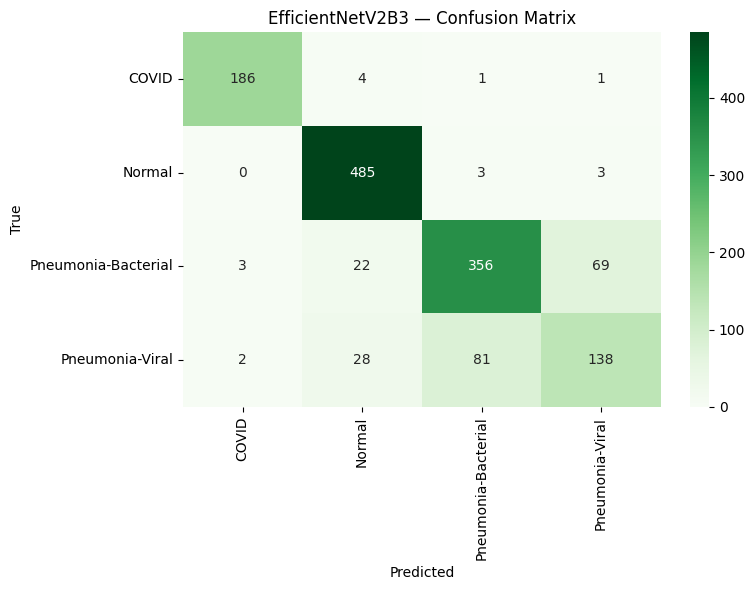

In [17]:
# ── 11. TEST EVALUATION ───────────────────────────────────────────────────────
test_gen.reset()
results = model.evaluate(test_gen, verbose=1)
print(f'\nTest Accuracy : {results[1]*100:.2f}%')
print(f'Test AUC      : {results[2]:.4f}')

test_gen.reset()
y_pred = np.argmax(model.predict(test_gen), axis=1)
y_true = test_gen.classes

print('\n📋 Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'{MODEL_NAME} — Confusion Matrix')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

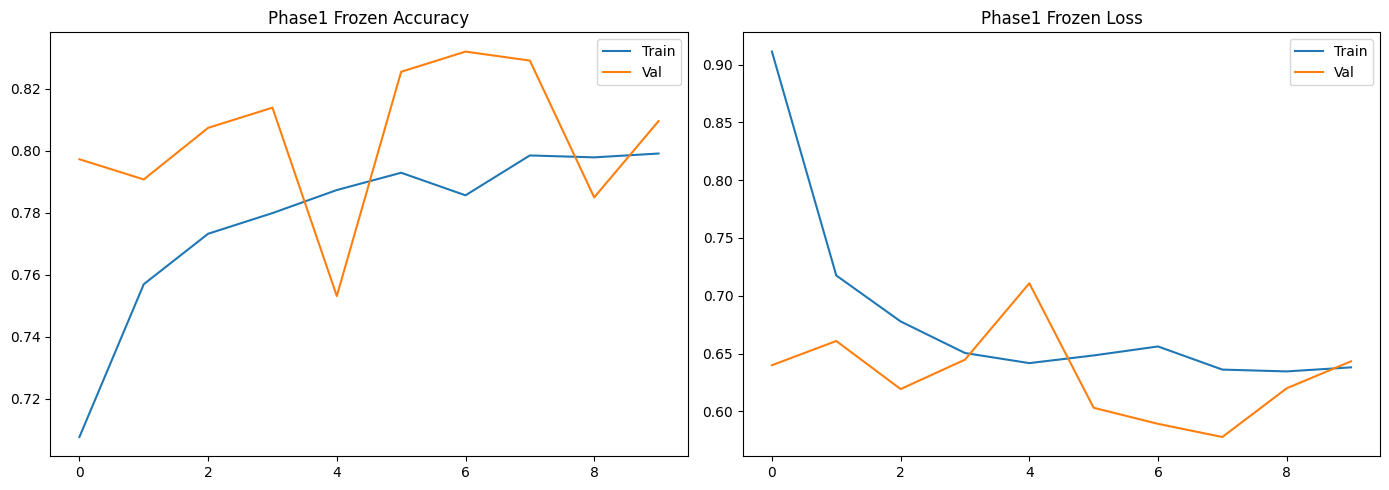

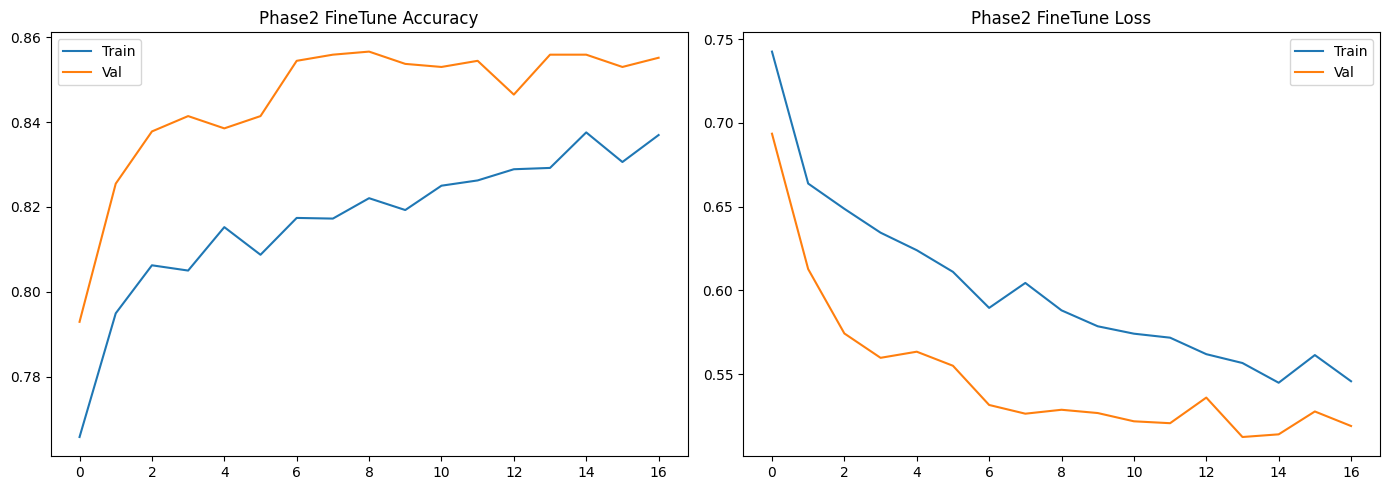

In [18]:
# ── 12. TRAINING CURVES ───────────────────────────────────────────────────────
def plot_log(log_path, title):
    if not os.path.exists(log_path): return
    df = pd.read_csv(log_path)
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].plot(df['accuracy'], label='Train'); ax[0].plot(df['val_accuracy'], label='Val')
    ax[0].set_title(f'{title} Accuracy'); ax[0].legend()
    ax[1].plot(df['loss'], label='Train'); ax[1].plot(df['val_loss'], label='Val')
    ax[1].set_title(f'{title} Loss'); ax[1].legend()
    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR, f'history_{title.replace(" ","_")}.png'), dpi=150)
    plt.show()

plot_log(LOG_FROZEN, 'Phase1 Frozen')
plot_log(LOG_FINE, 'Phase2 FineTune')

In [19]:
# ── 13. SAVE FINAL MODEL ──────────────────────────────────────────────────────
FINAL_PATH = os.path.join(WORK_DIR, f'{MODEL_NAME}_final.keras')
model.save(FINAL_PATH)
print(f'✅ Final model saved → {FINAL_PATH}')

✅ Final model saved → ./efficientnetv2b3_workspace\EfficientNetV2B3_final.keras
